# Regression Discontinuity Design (RDD)

In [1]:
!pip install rdrobust

## Scenario
The design of this example is inspired by Bermingham et al. (2021), but it is not a reproduction of their data or analysis. All numbers, values, and results are artificial and created solely to demonstrate the mechanics of Regression Discontinuity Design. Any resemblance to the published study’s results is coincidental and not intended to substitute for or replicate the original work.

Bermingham, C., Morgan, J., Ayoubkhani, D., Glickman, M., Islam, N., Sheikh, A., Sterne, J., Walker, A. S., & Nafilyan, V. (2023). Estimating the effectiveness of first dose of COVID-19 vaccine against mortality in England: A quasi-experimental study. American Journal of Epidemiology, 192(2), 267–275. https://doi.org/10.1093/aje/kwac157


## 1) Data Generation Process

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
np.random.seed(2025)

# -------------------------------------------------
# 1) Define the running variable and cutoff; build data
# -------------------------------------------------
# Synthetic population: ages 75–85 years
n = 20000
age_years = np.random.uniform(75, 85, size=n)
age_months = (age_years * 12).astype(int)
age = age_months / 12.0

# Running variable centered at 80 years (cutoff = 0)
running = age - 80.0
elig = (age >= 80.0).astype(int)  # eligibility indicator (instrument)

# Covariates
sex_male = np.random.binomial(1, 0.48, size=n)          # 1 = male
comorbidity = np.random.poisson(1.0, size=n)            # comorbidity index
imd = np.random.choice([1,2,3,4,5], size=n, 
                       p=[0.15,0.2,0.3,0.2,0.15])      # deprivation quintile

# Logistic helper
def logistic(x):
    return 1 / (1 + np.exp(-x))

# Vaccination probability: age slope + jump at cutoff
p_vax = logistic(-2.0 + 0.06 * running + 1.6 * elig 
                 - 0.05 * comorbidity + 0.12*(imd==5))
vaccinated = np.random.binomial(1, p_vax)

# Mortality probability: increases with age, comorbidity, IMD; reduced by vaccination
logodds_death = -4.0 + 0.25 * running + 0.9 * comorbidity + 0.35*(imd==5) - 1.2 * vaccinated
p_death = logistic(logodds_death)
death = np.random.binomial(1, p_death)

# Assemble dataframe and restrict window
df = pd.DataFrame({
    "age_years": age,
    "running": running,
    "elig": elig,
    "vaccinated": vaccinated,
    "p_vax": p_vax,
    "death": death,
    "p_death": p_death,
    "sex_male": sex_male,
    "comorbidity": comorbidity,
    "imd": imd
})

# Keep analysis window 75–85 years
df_rd = df[(df["age_years"] >= 75) & (df["age_years"] <= 85)].copy()
df_rd["running_sq"] = df_rd["running"] ** 2
df_rd.describe()

,age_years,running,elig,vaccinated,p_vax,death,p_death,sex_male,comorbidity,imd,running_sq
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,79.959288,-0.040713,0.49835,0.265100,0.264943,0.059200,0.059787,0.480350,1.011400,3.002000,8.249045
std,2.871898,2.871898,0.50001,0.441397,0.165103,0.236005,0.085258,0.499626,1.001759,1.256971,7.440040
min,75.000000,-5.000000,0.00000,0.000000,0.072426,0.000000,0.001578,0.000000,0.000000,1.000000,0.000000
25%,77.500000,-2.500000,0.00000,0.000000,0.101106,0.000000,0.014653,0.000000,0.000000,2.000000,1.562500
50%,79.916667,-0.083333,0.00000,0.000000,0.130108,0.000000,0.030769,0.000000,1.000000,3.000000,6.250000
75%,82.416667,2.416667,1.00000,1.000000,0.429228,0.000000,0.067810,1.000000,2.000000,4.000000,14.062500
max,84.916667,4.916667,1.00000,1.000000,0.503750,1.000000,0.936780,1.000000,7.000000,5.000000,25.000000


## rdrobust

In [3]:
# !pip install rdrobust


In [4]:
from rdrobust import rdrobust, rdbwselect, rdplot

c = 0.0 # the cutoff
t = df_rd['elig'] # Fuzzy RDD's treatment. Comment out if sharp RD
y = df_rd["death"].to_numpy()
x = df_rd["running"].to_numpy()

### Automatic bandwidth selection (CCT family) 

In [5]:
# (a) MSE
bw_mse = rdbwselect(y, x, c=c)
print("CCT MSE-optimal bandwidths:", bw_mse)

Mass points detected in the running variable.
CCT MSE-optimal bandwidths: Call: rdbwselect
Number of Observations:                 20000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

       h (left)  h (right)  b (left)  b (right)
mserd     1.251      1.251     2.415      2.415



In [6]:
# (b) Coverage-error-optimal bandwidths for robust bias-corrected CIs (recommended for inference)
bw_ce = rdbwselect(y, x, c=c, bwselect="cerrd")
print("CCT CE-optimal bandwidths:", bw_ce)

Mass points detected in the running variable.
CCT CE-optimal bandwidths: Call: rdbwselect
Number of Observations:                 20000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    cerrd
Var-Cov Estimator:                         NN

       h (left)  h (right)  b (left)  b (right)
cerrd     0.763      0.763     2.415      2.415



### RDD estimate with robust bias-corrected (CCT) inference

In [8]:
is_fuzzy = True
res_auto = rdrobust(y, x, c=c) if not is_fuzzy else rdrobust(y, x, c=c, fuzzy=t)
print("\n RDD results (automatic CCT selection)")
print(res_auto)

Mass points detected in the running variable.
Mass points detected in the running variable.

 RDD results (automatic CCT selection)
Call: rdrobust
Number of Observations:                 20000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations         10033       9967
Number of Unique Obs.             60         60
Number of Effective Obs.        2543       2697
Bandwidth Estimation           1.251      1.251
Bandwidth Bias                 2.415      2.415
rho (h/b)                      0.518      0.518

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.022    0.013   -1.745   

### RD plot (binscatter with local polynomial fits)

Mass points detected in the running variable.


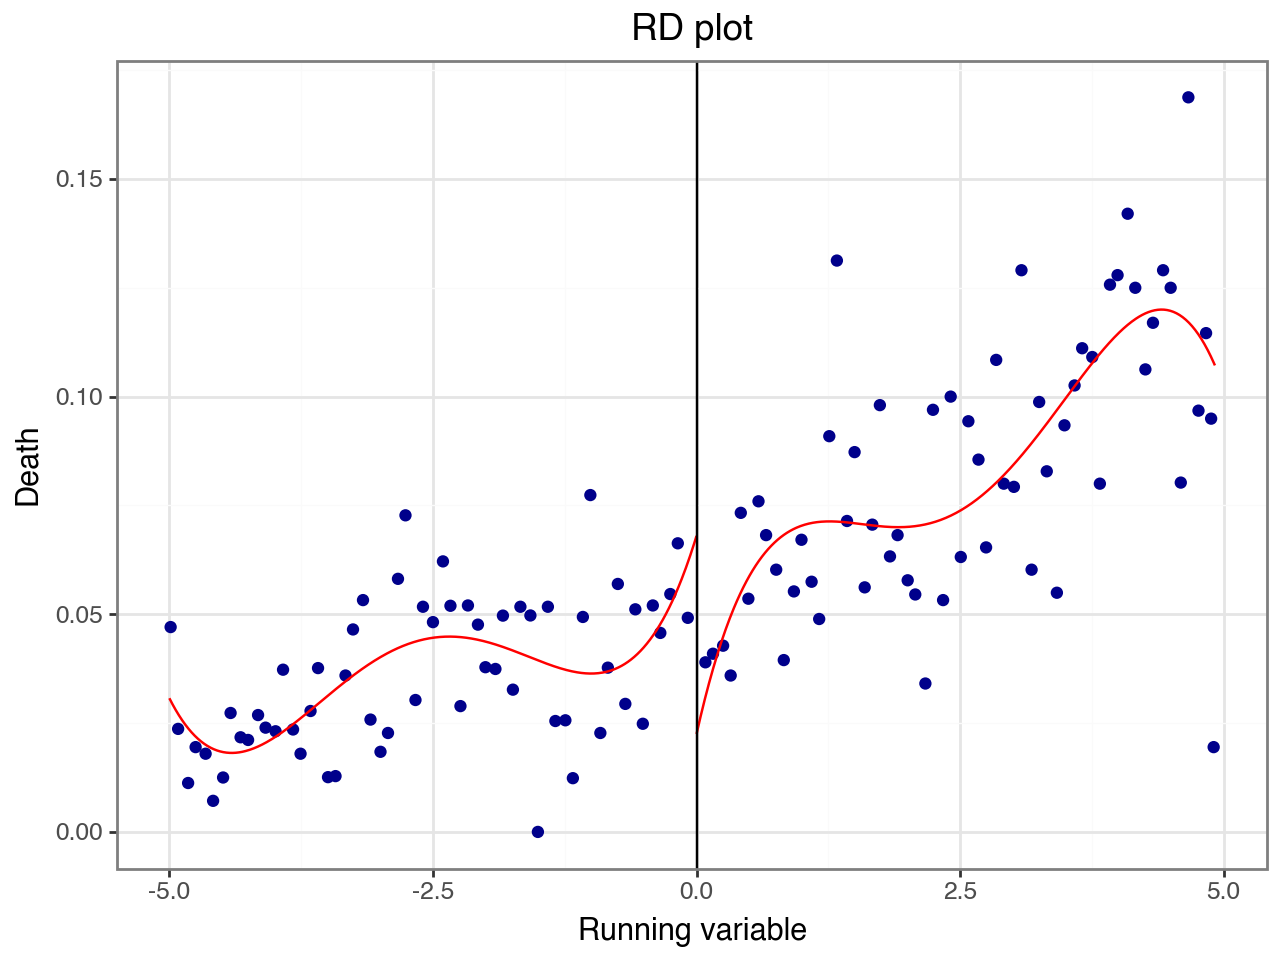

/opt/anaconda3/envs/py311/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
/opt/anaconda3/envs/py311/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide


In [9]:
fig = rdplot(y, x, c=c, title="RD plot", y_label="Death", x_label="Running variable")
#fig.save("rd_plot.png", dpi=300)

### Bandwidth sensitivity test multipliers (0.5x, 1x, 2x)

In [52]:
candidate_h = [2.0, 4.0, 8.0]
print("\n--- Bandwidth sensitivity (scalar h on both sides) ---")
for h in candidate_h:
    res_h = (rdrobust(y, x, c=c, h=h)
            if not is_fuzzy else rdrobust(y, x, c=c, fuzzy=t, h=h))
    print(f"\n[h = {h:.3f}]")
    print(res_h)


--- Bandwidth sensitivity (scalar h on both sides) ---
Mass points detected in the running variable.

[h = 2.000]
Call: rdrobust
Number of Observations:                 20000
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                   Manual
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations         10033       9967
Number of Unique Obs.             60         60
Number of Effective Obs.        3911       4009
Bandwidth Estimation             2.0        2.0
Bandwidth Bias                   2.0        2.0
rho (h/b)                        1.0        1.0

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.018     0.01   -1.742   8.147e-02    [-0.

## (2) Manual Estimation Using 2SLS
### (2.1) Manual 2SLS 
#### (2.1.1) Stage 1: vaccinated ~ elig + running + running_sq

In [53]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# --- First stage: vaccinated on instrument + controls (HC1 robust SEs)
fs = smf.ols("vaccinated ~ elig + running + running_sq", data=df_rd).fit(cov_type="HC1")
print(fs.summary())

# Predicted treatment (t_hat)
df_rd["t_hat"] = fs.fittedvalues

                            OLS Regression Results                            
Dep. Variable:             vaccinated   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.141
Method:                 Least Squares   F-statistic:                     1098.
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        23:55:14   Log-Likelihood:                -10503.
No. Observations:               20000   AIC:                         2.101e+04
Df Residuals:                   19996   BIC:                         2.105e+04
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1210      0.006     21.546      0.0

**Interpretation:**
- Eligibility is a strong predictor of vaccination: Crossing the eligibility cutoff increases the probability of being vaccinated by  0.2817 (p < 0.001).
- Instrument strength: The eligibility indicator is **highly statistically significant** (z = 24.4), indicating a **very strong first stage** with no evidence of a weak instrument problem.
- Baseline vaccination rate: At the cutoff (running = 0) and just below eligibility, the predicted vaccination rate is about 0.121.
- Running variable controls: Vaccination uptake increases smoothly with the running variable (coef = 0.0098, p < 0.001), suggesting higher baseline take‑up as the forcing variable increases.
- Nonlinearity: The quadratic term is small and statistically insignificant, implying that **most of the smooth relationship is linear** near the cutoff.
- Model fit: The model explains about **14% of the variation** in vaccination status (R² = 0.141), which is relatively high for a binary first‑stage outcome.

**Conclusion:**
Eligibility induces a **large, sharp discontinuity in vaccination**, satisfying the **relevance condition** for IV estimation.


#### (2.1.2) Stage 2: death ~ t_hat + running + running_sq

In [54]:
# --- Second stage: outcome on predicted treatment + controls (HC1 robust SEs)
s2 = smf.ols("death ~ t_hat + running + running_sq", data=df_rd).fit(cov_type="HC1")
print(s2.summary())

                            OLS Regression Results                            
Dep. Variable:                  death   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     87.54
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.85e-56
Time:                        23:55:15   Log-Likelihood:                 646.51
No. Observations:               20000   AIC:                            -1285.
Df Residuals:                   19996   BIC:                            -1253.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0578      0.006      9.836      0.0

**Interpretation:**
- Causal effect (LATE) of vaccination on mortality: The coefficient on `t_hat` is **−0.0219** (SE = 0.022, **p = 0.324**, 95% CI **\[−0.065, 0.022]**). Vaccination is associated with a **0.022 lower** probability of death **for compliers**, but the effect is **not statistically significant**.
- Consistency with Wald calculation: Using the reduced form (−0.0062) and first stage (0.2817), the Wald estimate is **−0.0062 / 0.2817 ≈ −0.022**, which matches the second‑stage coefficient—good internal consistency.
- Baseline level at the cutoff: The intercept (**0.0578**) implies a **\~5.8%** mortality probability at the cutoff (holding running = 0).
- Running variable controls:  `running` (**0.0108**, p < 0.001) and `running_sq` (**0.0009**, p < 0.001) are positive—mortality **rises and does so convexly** as the running variable increases.

### (2.2) Reduced-form OLS
death ~ elig + running + running_sq

In [55]:
X_rf = sm.add_constant(df_rd[["elig", "running", "running_sq"]])
rf_model = sm.OLS(df_rd["death"], X_rf).fit(cov_type="HC1")
print(rf_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  death   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     87.54
Date:                Wed, 18 Feb 2026   Prob (F-statistic):           2.85e-56
Time:                        23:55:16   Log-Likelihood:                 646.51
No. Observations:               20000   AIC:                            -1285.
Df Residuals:                   19996   BIC:                            -1253.
Df Model:                           3                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0552      0.004     15.446      0.0

### (2.3) 2SLS using linearmodels

In [56]:
!pip install linearmodels

In [57]:
# !pip install linearmodels  # if needed
from linearmodels.iv import IV2SLS
import pandas as pd

# Design matrices: include the same controls in both stages
y = df_rd["death"]
X = sm.add_constant(df_rd[["running", "running_sq"]])  # exogenous controls
D = df_rd["vaccinated"]                                # endogenous regressor
Z = df_rd["elig"]                                      # instrument

iv2sls = IV2SLS(dependent=y, exog=X, endog=D, instruments=Z).fit(cov_type="robust")  # robust ~ HC1
print(iv2sls.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:                  death   R-squared:                      0.0206
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0205
No. Observations:               20000   F-statistic:                    264.35
Date:                Wed, Feb 18 2026   P-value (F-stat)                0.0000
Time:                        23:55:18   Distribution:                  chi2(3)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const          0.0578     0.0059     9.8548     0.0000      0.0463      0.0693
running        0.0108     0.0013     8.1175     0.00

**Interpretation:**
- Causal effect (LATE) of vaccination on mortality: The IV coefficient on **`vaccinated` = −0.0219** (SE = 0.0222, **p = 0.323**, 95% CI **\[−0.0654, 0.0215]**). It is the **local average treatment effect at the cutoff**. It means vaccination is associated with a **0.022 lower** probability of death for **compliers**, but the effect is **not statistically distinguishable from zero**. This -0.022 is consistent with the 2SLS results.
- Controls / running variable: `running` (**0.0108**, p < 0.001) and `running_sq` (**0.0009**, p < 0.001) are positive—mortality **increases and does so convexly** as the running variable grows, consistent with strong smooth trends.
- Baseline level at the cutoff:  **Intercept = 0.0578**. It means mortality probability at the cutoff (holding the running variable at 0).

**Conclusion:** IV–2SLS shows no statistically significant effect of vaccination on mortality at the eligibility cutoff (LATE ≈ −2.2 p.p., p = 0.32), despite a strong first stage and pronounced smooth trends in the running variable.
